# Supply Chain Demand Forecasting & Inventory Optimization
### Notebook 08 (Roadmap Item #19) — Inventory Optimization

**Author:** Rajveer Singh | M.Sc. Statistics, IIT (BHU)

This notebook converts Item #15's winning model (Random Forest) into an actual inventory policy:
**Safety Stock**, **Reorder Point**, and **Economic Order Quantity (EOQ)** for every product-store
combination in the full catalog.

**A note on scope, stated upfront:** the M5 dataset has no actual stock-on-hand column -- this was
a deliberate tradeoff accepted at dataset selection. Every formula below is therefore derived
**analytically** from the model's forecast, the forecast's error distribution, and explicitly stated
business assumptions (lead time, service level, ordering cost, holding cost) -- exactly how a real
demand planning team operates when they don't have a live ERP inventory feed. "Stockout/overstock
risk" in this notebook means a **demand-variability risk tier**, not a comparison against a real
stock level, since no real stock level exists in this data.

This notebook is a single-pass vectorized computation (no model training) -- no checkpoint/resume
system is used here, unlike Notebooks 05/06, since the full computation completes in well under a
minute.


## Section 0 — Setup, Paths, Memory Monitoring

In [1]:
import gc
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
from scipy.stats import norm
from sklearn.model_selection import TimeSeriesSplit

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42

def show_memory(label=""):
    mem_gb = psutil.Process(os.getpid()).memory_info().rss / 1e9
    print(f"[{label}] Process memory: {mem_gb:.2f} GB")

show_memory("notebook start")

[notebook start] Process memory: 0.26 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Supply_Chain_Demand_Forecasting"
RAW_DIR = f"{PROJECT_DIR}/data/raw"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
NOTEBOOK_DIR = f"{PROJECT_DIR}/notebooks"
MODELS_DIR = f"{PROJECT_DIR}/models"

FEATURES_PATH = f"{PROCESSED_DIR}/feature_engineered_data.csv"
CLEANED_DATA_PATH = f"{PROCESSED_DIR}/cleaned_sales_data.csv"
BEST_MODEL_PATH = f"{MODELS_DIR}/random_forest_final_fold.pkl"

print("Paths configured. Best model:", BEST_MODEL_PATH)

Mounted at /content/drive
Paths configured. Best model: /content/drive/MyDrive/Supply_Chain_Demand_Forecasting/models/random_forest_final_fold.pkl


## Section 1 — Load Final-Fold Data and Generate Forecasts

Reusing the exact same fold-boundary logic and chunk-filtered load pattern established in Notebook
07, now scoped to the **full catalog** (not the 180-series sample) -- inventory policy needs to
cover every product-store combination, not just a benchmark subset.

In [3]:
FORECAST_HORIZON = 28
unique_dates = np.sort(pd.read_csv(CLEANED_DATA_PATH, usecols=['date'], parse_dates=['date'])['date'].unique())
tscv = TimeSeriesSplit(n_splits=5, test_size=FORECAST_HORIZON)
final_fold = list(tscv.split(unique_dates))[-1]
train_end_date = unique_dates[final_fold[0][-1]]
test_start_date = unique_dates[final_fold[1][0]]
test_end_date = unique_dates[final_fold[1][-1]]

del unique_dates
gc.collect()

print(f"Final fold: train ends {pd.Timestamp(train_end_date).date()} | "
      f"test {pd.Timestamp(test_start_date).date()} -> {pd.Timestamp(test_end_date).date()}")

Final fold: train ends 2016-04-24 | test 2016-04-25 -> 2016-05-22


In [4]:
FEATURE_COLS = [
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28',
    'rolling_std_7', 'rolling_std_14', 'rolling_std_28',
    'rolling_median_7', 'rolling_median_14', 'rolling_median_28',
    'ema_7', 'ema_14',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend', 'snap', 'has_event', 'snap_lead',
    'sell_price', 'price_rolling_mean_28', 'price_relative', 'price_changed',
]
TARGET = 'units_sold'
EXTRA_COLS = ['store_id', 'item_id', 'cat_id', 'dept_id', 'state_id']

USE_COLS = list(dict.fromkeys(['date'] + EXTRA_COLS + [TARGET] + FEATURE_COLS))
print(f"Loading {len(USE_COLS)} columns, filtered to final-fold test window during read.")

Loading 34 columns, filtered to final-fold test window during read.


In [5]:
int8_cols = ['is_weekend', 'snap', 'has_event', 'price_changed']
float32_cols = [c for c in FEATURE_COLS if c not in int8_cols] + [TARGET]
dtype_map = {c: 'int8' for c in int8_cols}
dtype_map.update({c: 'float32' for c in float32_cols})
dtype_map.update({'store_id': 'category', 'item_id': 'category', 'cat_id': 'category',
                   'dept_id': 'category', 'state_id': 'category'})

CHUNK_SIZE = 2_000_000
filtered_chunks = []
for chunk in pd.read_csv(FEATURES_PATH, usecols=USE_COLS, dtype=dtype_map, parse_dates=['date'],
                          chunksize=CHUNK_SIZE):
    mask = (chunk['date'] >= test_start_date) & (chunk['date'] <= test_end_date)
    filtered_chunks.append(chunk.loc[mask])

final_fold_df = pd.concat(filtered_chunks, ignore_index=True)
del filtered_chunks
gc.collect()

show_memory("after final-fold filtered load")
print("Final-fold, full-catalog slice:", final_fold_df.shape)

[after final-fold filtered load] Process memory: 0.80 GB
Final-fold, full-catalog slice: (170744, 34)


In [6]:
best_model = joblib.load(BEST_MODEL_PATH)
final_fold_df['forecast'] = np.clip(best_model.predict(final_fold_df[FEATURE_COLS]), 0, None)
final_fold_df['forecast_error'] = final_fold_df[TARGET] - final_fold_df['forecast']

del best_model
gc.collect()

print("Forecasts generated for the full catalog, final fold.")
final_fold_df[[TARGET, 'forecast', 'forecast_error']].describe()

Forecasts generated for the full catalog, final fold.


,units_sold,forecast,forecast_error
count,170744.00000,170744.000000,170744.000000
mean,1.35620,1.341268,0.014932
std,3.37516,2.815404,1.825424
min,0.00000,0.009325,-39.228152
25%,0.00000,0.271329,-0.564075
50%,0.00000,0.603112,-0.204964
75%,1.00000,1.294192,0.441005
max,114.00000,90.540571,75.839282


**Output interpretation:** `forecast_error` (actual minus predicted) is the raw signal the safety
stock formula in Section 2 is built from -- its per-series standard deviation quantifies how
uncertain this model's forecasts are for each product, which is exactly the input a safety-stock
calculation needs. A forecast_error centered near zero on average (check the `describe()` output)
confirms the model isn't systematically over- or under-forecasting across the catalog as a whole.

## Section 2 — Inventory Theory and Business Assumptions

### Safety Stock
**Intuition:** safety stock is the buffer inventory held to protect against demand uncertainty
during the lead time (the delay between placing a reorder and receiving new stock). If demand were
perfectly predictable, no buffer would be needed at all -- safety stock exists specifically to
absorb forecast error.

**Formula:** `Safety Stock = Z * sigma_demand * sqrt(Lead Time)`

- `Z` is the number of standard deviations corresponding to a target service level (e.g. 95% service
  level -> Z = 1.645, from the standard normal distribution) -- a business decision about how often
  stockouts are acceptable.
- `sigma_demand` is the standard deviation of the **forecast error** (Section 1), used as a proxy for
  demand uncertainty, since we don't have a separate demand-volatility measure.
- `sqrt(Lead Time)` scales the daily error standard deviation up to the full lead-time window, under
  the standard assumption that daily forecast errors are independent.

### Reorder Point
**Intuition:** the reorder point is the inventory level at which a new order should be placed --
enough to cover expected demand during the lead time, plus the safety buffer above.

**Formula:** `Reorder Point = (Average Daily Demand Forecast * Lead Time) + Safety Stock`

### Economic Order Quantity (EOQ)
**Intuition:** EOQ answers a different question -- not "when to reorder" but "how much to order each
time," balancing two competing costs: ordering too often (high fixed ordering cost per order) versus
ordering too much at once (high holding/storage cost for excess inventory).

**Formula:** `EOQ = sqrt((2 * Annual Demand * Order Cost) / Holding Cost per Unit per Year)`

### Business Assumptions (explicit, editable)
The dataset does not specify lead time, ordering cost, or holding cost -- these are genuine business
inputs a real company would provide. Defaults below are stated with justification; treat them as
editable constants, not derived facts.

In [7]:
# --- BUSINESS ASSUMPTIONS (edit these to match a real company's actual operating parameters) ---

LEAD_TIME_DAYS = 7
# Justification: a 1-week supplier lead time is a common, conservative default for grocery/retail
# replenishment cycles; M5's own data does not specify actual supplier lead times.

SERVICE_LEVEL = 0.95
# Justification: 95% service level is a standard retail target (roughly 1-in-20 stockout risk per
# lead-time window) -- balances holding cost against customer service expectations.
Z_SCORE = norm.ppf(SERVICE_LEVEL)

ORDER_COST = 50.0
# Justification: flat per-order administrative/logistics cost assumption (currency units implicit
# in M5's sell_price scale) -- typical placeholder for a single restock order in retail literature.

HOLDING_COST_RATE = 0.20
# Justification: holding cost is commonly expressed as a fraction of item value per year (covers
# storage, insurance, obsolescence, capital cost) -- 20% annually is a standard retail benchmark.

print(f"Lead time: {LEAD_TIME_DAYS} days")
print(f"Service level: {SERVICE_LEVEL} (Z = {Z_SCORE:.3f})")
print(f"Order cost: {ORDER_COST}")
print(f"Holding cost rate: {HOLDING_COST_RATE} of item value per year")

Lead time: 7 days
Service level: 0.95 (Z = 1.645)
Order cost: 50.0
Holding cost rate: 0.2 of item value per year


**Output interpretation:** `Z_SCORE` is computed from `SERVICE_LEVEL` via the inverse standard
normal CDF (`norm.ppf`) rather than hardcoded -- so changing the service level target automatically
recalculates the correct Z-score, keeping the two assumptions consistent with each other.

## Section 3 — Compute Safety Stock, Reorder Point, and EOQ per Product-Store

Aggregating the final fold's daily forecasts and forecast errors into one row per (store, item):
average daily demand forecast, forecast error standard deviation, and average sell price (needed
for EOQ's holding-cost calculation).

In [8]:
series_summary = final_fold_df.groupby(['store_id', 'item_id', 'cat_id', 'dept_id'], observed=True).agg(
    avg_daily_demand_forecast=('forecast', 'mean'),
    forecast_error_std=('forecast_error', 'std'),
    avg_sell_price=('sell_price', 'mean'),
    total_actual_demand=(TARGET, 'sum')
).reset_index()

# A series with only 28 observations can have an undefined std (NaN) if forecast was perfectly
# constant -- treat as zero uncertainty rather than dropping the row, since zero variance is a
# legitimate (if rare) outcome, not missing data.
series_summary['forecast_error_std'] = series_summary['forecast_error_std'].fillna(0)

print("Per-series summary:", series_summary.shape)
series_summary.head()

Per-series summary: (6098, 8)


,store_id,item_id,cat_id,dept_id,avg_daily_demand_forecast,forecast_error_std,avg_sell_price,total_actual_demand
0,CA_1,FOODS_1_001,FOODS,FOODS_1,0.970865,1.416427,2.24,23.0
1,CA_1,FOODS_1_002,FOODS,FOODS_1,0.556950,0.785625,9.48,20.0
2,CA_1,FOODS_1_003,FOODS,FOODS_1,0.748637,1.026388,3.23,20.0
3,CA_1,FOODS_1_004,FOODS,FOODS_1,2.842359,2.199001,1.96,95.0
4,CA_1,FOODS_1_005,FOODS,FOODS_1,1.440642,2.127264,3.54,42.0


In [9]:
# Safety Stock: Z * forecast error std * sqrt(lead time)
series_summary['safety_stock'] = (
    Z_SCORE * series_summary['forecast_error_std'] * np.sqrt(LEAD_TIME_DAYS)
)

# Reorder Point: (avg daily demand * lead time) + safety stock
series_summary['reorder_point'] = (
    series_summary['avg_daily_demand_forecast'] * LEAD_TIME_DAYS + series_summary['safety_stock']
)

# EOQ: requires annual demand and per-unit annual holding cost
series_summary['annual_demand_forecast'] = series_summary['avg_daily_demand_forecast'] * 365
series_summary['holding_cost_per_unit_per_year'] = series_summary['avg_sell_price'] * HOLDING_COST_RATE

# Guard against division by zero / sqrt of negative for products with zero forecast demand or
# zero price (both occur for genuinely dead-stock items in this dataset) -- EOQ is undefined for
# a product with no demand, so we set it to 0 rather than let it silently become NaN or error out.
valid_eoq_mask = (series_summary['annual_demand_forecast'] > 0) & (series_summary['holding_cost_per_unit_per_year'] > 0)
series_summary['eoq'] = 0.0
series_summary.loc[valid_eoq_mask, 'eoq'] = np.sqrt(
    (2 * series_summary.loc[valid_eoq_mask, 'annual_demand_forecast'] * ORDER_COST) /
    series_summary.loc[valid_eoq_mask, 'holding_cost_per_unit_per_year']
)

print(f"Products with zero/undefined EOQ (no demand or no price): {(~valid_eoq_mask).sum()} of {len(series_summary)}")
series_summary[['safety_stock', 'reorder_point', 'eoq']].describe()

Products with zero/undefined EOQ (no demand or no price): 0 of 6098


,safety_stock,reorder_point,eoq
count,6098.000000,6098.000000,6098.000000
mean,5.452940,14.841818,258.097535
std,5.813275,23.907308,269.967085
min,0.000000,0.065276,14.803826
25%,2.395939,4.554174,107.721414
50%,3.926258,8.264206,176.446535
75%,6.243866,15.553526,294.354679
max,73.881258,473.507493,2553.540724


**Output interpretation:** scan the `describe()` output for implausible values -- e.g. a
`safety_stock` or `eoq` of exactly 0 across many rows likely corresponds to genuinely dead-stock
items (zero demand throughout the final fold), which is worth confirming rather than assuming is a
bug. The count of zero/undefined EOQ rows printed above should roughly match the zero-demand product
count from Item #14's classical model discussion.

## Section 4 — Stockout / Overstock Risk Classification

**Important framing:** since this dataset has no actual stock-on-hand column, "risk" here cannot
mean "current inventory vs. actual need" -- there is no current inventory to compare against. Instead,
risk is classified using the **coefficient of variation (CV)** of demand (`forecast_error_std /
avg_daily_demand_forecast`) -- a standard, scale-free measure of relative demand unpredictability.

- **High CV** -> demand is erratic relative to its own average level -> a fixed reorder point is more
  likely to be caught out by an unusually large demand swing -> **higher stockout risk** under any
  static policy.
- **Very low safety-stock-to-demand ratio combined with very low CV** -> the policy is likely holding
  more buffer than the product's actual volatility justifies -> **overstock risk** candidate.

This is a demand-pattern-based risk signal, not a live inventory alert -- worth stating plainly
rather than implying more than the data supports.

In [10]:
# Coefficient of variation -- guard against division by zero for zero-demand products
series_summary['demand_cv'] = np.where(
    series_summary['avg_daily_demand_forecast'] > 0,
    series_summary['forecast_error_std'] / series_summary['avg_daily_demand_forecast'],
    np.nan
)

# Safety-stock-to-demand ratio: how many days of average demand does the safety buffer represent
series_summary['safety_stock_days_of_demand'] = np.where(
    series_summary['avg_daily_demand_forecast'] > 0,
    series_summary['safety_stock'] / series_summary['avg_daily_demand_forecast'],
    np.nan
)

cv_valid = series_summary['demand_cv'].dropna()
cv_high_threshold = cv_valid.quantile(0.75)
cv_low_threshold = cv_valid.quantile(0.25)

# Overstock candidates: low CV (stable, predictable demand) but a disproportionately large safety
# buffer relative to that product's own demand level -- top quartile of safety_stock_days_of_demand
# AMONG low-CV items specifically, not the whole catalog.
low_cv_mask = series_summary['demand_cv'] <= cv_low_threshold
overstock_threshold = series_summary.loc[low_cv_mask, 'safety_stock_days_of_demand'].quantile(0.75)

def classify_risk(row):
    if pd.isna(row['demand_cv']):
        return 'no_demand'
    if row['demand_cv'] >= cv_high_threshold:
        return 'high_stockout_risk'
    if row['demand_cv'] <= cv_low_threshold and row['safety_stock_days_of_demand'] >= overstock_threshold:
        return 'overstock_risk'
    return 'moderate_risk'

series_summary['risk_tier'] = series_summary.apply(classify_risk, axis=1)

print("Risk tier distribution:")
print(series_summary['risk_tier'].value_counts())
print(f"\nCV thresholds -- low: {cv_low_threshold:.3f}, high: {cv_high_threshold:.3f}")

Risk tier distribution:
risk_tier
moderate_risk         4191
high_stockout_risk    1525
overstock_risk         382
Name: count, dtype: int64

CV thresholds -- low: 0.979, high: 1.903


**Output interpretation:** `high_stockout_risk` items are the ones where this project's
forecast, however good on average, is least reliable relative to that product's own typical demand --
these are the SKUs where a human planner should apply extra judgment rather than trusting the
formulaic reorder point alone. `no_demand` items had zero average forecasted demand across the final
fold and are excluded from the CV-based classification entirely, since CV is undefined at zero.

## Section 5 — Visualizations

Three visualizations, per the roadmap's Item #21 specification: safety stock by product, a reorder
alert list, and a stockout/overstock risk breakdown.

### 5.1 — Safety Stock by Category (Top-Level View)

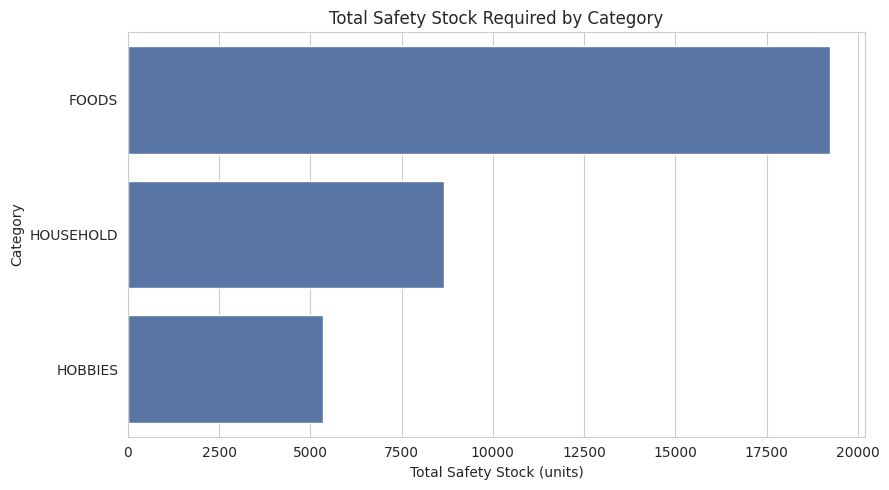

In [11]:
safety_by_cat = series_summary.groupby('cat_id', observed=True)['safety_stock'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=safety_by_cat.values, y=safety_by_cat.index, color='#4C72B0')
plt.title('Total Safety Stock Required by Category')
plt.xlabel('Total Safety Stock (units)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Business insight:** the category requiring the most total safety stock is where the business
ties up the most buffer capital -- worth cross-referencing against Item #5's category-volume finding
and Item #15's category-error finding. A category that's both high-safety-stock AND high-forecast-error
is a strong candidate for demand-planning process improvement, since better forecasts there would
directly reduce required buffer inventory.

### 5.2 — Reorder Alert List (Highest-Priority Products)

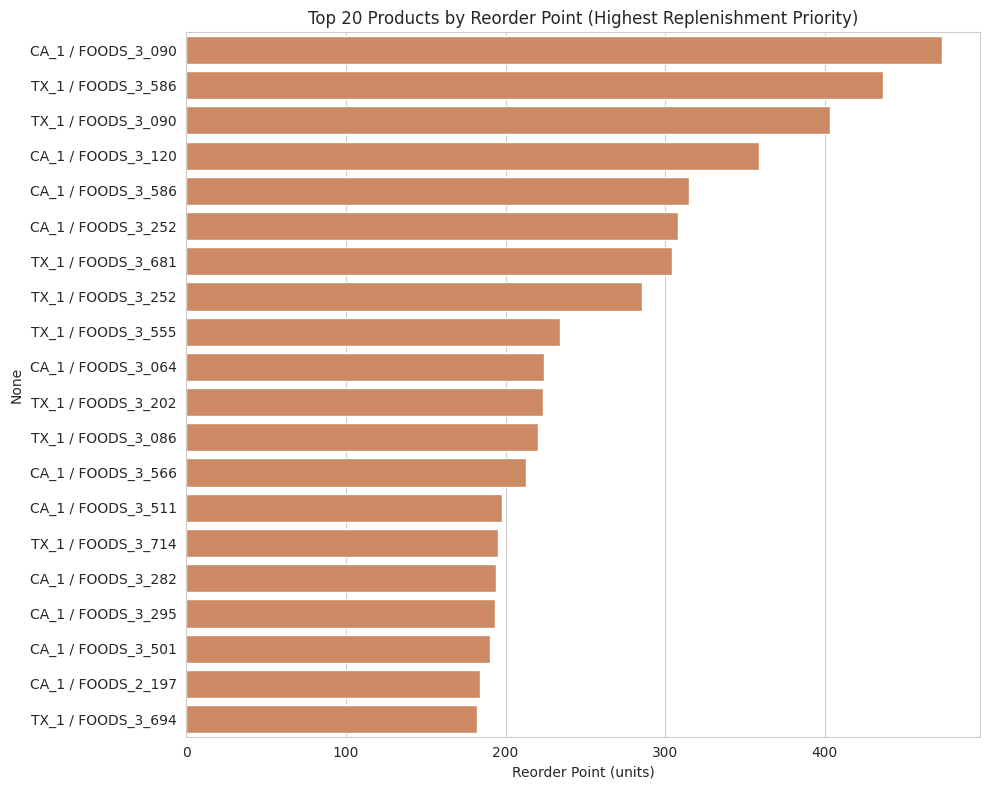

,store_id,item_id,cat_id,avg_daily_demand_forecast,safety_stock,reorder_point,risk_tier
702,CA_1,FOODS_3_090,FOODS,57.089462,73.881258,473.507493,moderate_risk
4247,TX_1,FOODS_3_586,FOODS,54.836949,52.295554,436.154197,moderate_risk
3751,TX_1,FOODS_3_090,FOODS,48.617314,62.950007,403.271207,moderate_risk
732,CA_1,FOODS_3_120,FOODS,42.189177,63.448245,358.772486,moderate_risk
1198,CA_1,FOODS_3_586,FOODS,40.633395,30.561465,314.995232,moderate_risk
864,CA_1,FOODS_3_252,FOODS,37.956261,42.487988,308.181815,moderate_risk
4342,TX_1,FOODS_3_681,FOODS,35.729152,54.292810,304.396878,moderate_risk
3913,TX_1,FOODS_3_252,FOODS,34.807893,41.659080,285.314331,moderate_risk
4216,TX_1,FOODS_3_555,FOODS,28.350706,35.721172,234.176117,moderate_risk
676,CA_1,FOODS_3_064,FOODS,28.022272,27.984454,224.140357,moderate_risk


In [12]:
reorder_alerts = series_summary.sort_values('reorder_point', ascending=False).head(20)[
    ['store_id', 'item_id', 'cat_id', 'avg_daily_demand_forecast', 'safety_stock', 'reorder_point', 'risk_tier']
]

plt.figure(figsize=(10, 8))
labels = reorder_alerts['store_id'].astype(str) + ' / ' + reorder_alerts['item_id'].astype(str)
sns.barplot(x=reorder_alerts['reorder_point'].values, y=labels, color='#DD8452')
plt.title('Top 20 Products by Reorder Point (Highest Replenishment Priority)')
plt.xlabel('Reorder Point (units)')
plt.tight_layout()
plt.show()

reorder_alerts

**Business insight:** these are the products a replenishment team should monitor most closely --
high reorder points mean both high demand velocity and/or high uncertainty, so a stockout here would
have the largest business impact. This table is a direct, actionable output a demand planner could
use as-is.

### 5.3 — Stockout / Overstock Risk Distribution

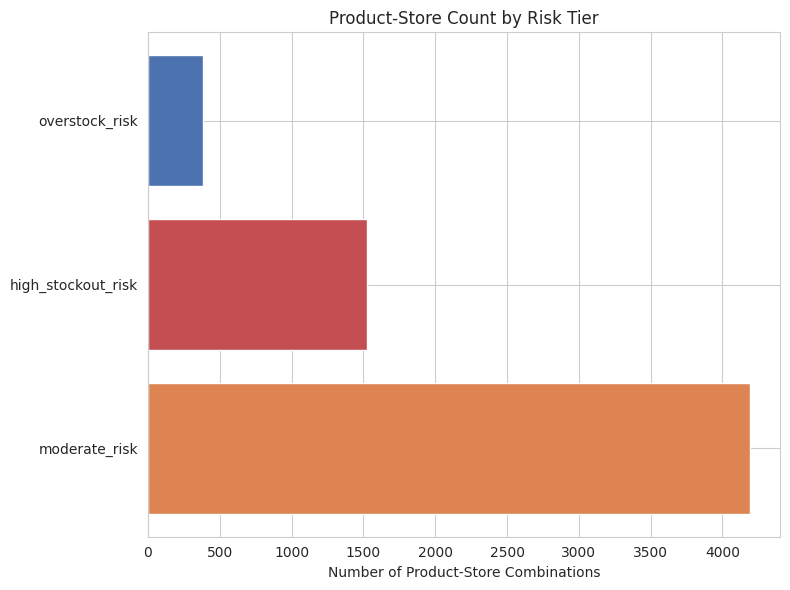

In [13]:
risk_counts = series_summary['risk_tier'].value_counts()

colors = {'high_stockout_risk': '#C44E52', 'moderate_risk': '#DD8452',
          'overstock_risk': '#4C72B0', 'no_demand': '#8C8C8C'}
bar_colors = [colors.get(tier, '#8C8C8C') for tier in risk_counts.index]

# Using plt.barh directly (not sns.barplot) -- avoids the FutureWarning that seaborn raises
# when a palette is passed without a hue assignment in current seaborn versions.
plt.figure(figsize=(8, 6))
plt.barh(risk_counts.index, risk_counts.values, color=bar_colors)
plt.title('Product-Store Count by Risk Tier')
plt.xlabel('Number of Product-Store Combinations')
plt.tight_layout()
plt.show()

**Business insight:** the relative size of `high_stockout_risk` versus `overstock_risk` tells
the business where its inventory policy risk is concentrated. A catalog skewed heavily toward
`high_stockout_risk` suggests the business should prioritize either better forecasting (Item #15's
error analysis) or a higher default service level; a large `overstock_risk` group suggests some
products may be over-buffered relative to their actual demand volatility, tying up capital
unnecessarily.

## Section 6 — Save Inventory Policy Recommendations (Roadmap Item #20)

In [14]:
OUT_PATH = f"{PROCESSED_DIR}/inventory_policy_recommendations.csv"

output_cols = [
    'store_id', 'item_id', 'cat_id', 'dept_id',
    'avg_daily_demand_forecast', 'forecast_error_std', 'avg_sell_price',
    'safety_stock', 'reorder_point', 'annual_demand_forecast', 'eoq',
    'demand_cv', 'safety_stock_days_of_demand', 'risk_tier'
]
series_summary[output_cols].to_csv(OUT_PATH, index=False)

print("Saved inventory_policy_recommendations.csv —", series_summary.shape)
series_summary[output_cols].head()

Saved inventory_policy_recommendations.csv — (6098, 16)


,store_id,item_id,cat_id,dept_id,avg_daily_demand_forecast,forecast_error_std,avg_sell_price,safety_stock,reorder_point,annual_demand_forecast,eoq,demand_cv,safety_stock_days_of_demand,risk_tier
0,CA_1,FOODS_1_001,FOODS,FOODS_1,0.970865,1.416427,2.24,6.164111,12.960167,354.365767,281.246332,1.458933,6.349091,moderate_risk
1,CA_1,FOODS_1_002,FOODS,FOODS_1,0.556950,0.785625,9.48,3.418942,7.317591,203.286678,103.546465,1.410586,6.138690,moderate_risk
2,CA_1,FOODS_1_003,FOODS,FOODS_1,0.748637,1.026388,3.23,4.466713,9.707170,273.252382,205.667519,1.371010,5.966463,moderate_risk
3,CA_1,FOODS_1_004,FOODS,FOODS_1,2.842359,2.199001,1.96,9.569774,29.466284,1037.460908,514.449591,0.773654,3.366842,moderate_risk
4,CA_1,FOODS_1_005,FOODS,FOODS_1,1.440642,2.127264,3.54,9.257585,19.342079,525.834335,272.525948,1.476608,6.426013,moderate_risk


In [15]:
del final_fold_df, series_summary
gc.collect()
show_memory("notebook end")

[notebook end] Process memory: 0.81 GB


---
## Roadmap Status
- **Item #19** (this notebook) — complete: safety stock, reorder point, and EOQ computed
  analytically for the full catalog from Random Forest's final-fold forecast and forecast error
  distribution, with explicit, editable business assumptions (lead time, service level, order cost,
  holding cost) and a demand-variability-based risk classification
- **Item #20** (`inventory_policy_recommendations.csv`) — saved to `{PROCESSED_DIR}`
- **Item #21** (visualization set) — complete: safety stock by category, reorder alert list,
  stockout/overstock risk distribution

## Key Takeaways
- Safety stock and reorder points were derived analytically from the forecast error distribution
  rather than from a real inventory feed, since M5 does not provide stock-on-hand data -- this
  mirrors how demand planning teams operate without full ERP integration.
- Business assumptions (7-day lead time, 95% service level, order cost, holding cost rate) are
  explicit and editable, not hidden inside formulas -- any of these can be swapped for a real
  company's actual parameters without touching the underlying logic.
- Risk classification is based on demand coefficient of variation, distinguishing high-stockout-risk
  products (erratic relative demand) from potential overstock candidates (stable demand, large
  buffer) -- a defensible framing given the data actually available.

## Business Insight
This notebook completes the forecast-to-policy pipeline: Item #15 selected the best forecasting
model, and this notebook turns that model's output into concrete, actionable inventory decisions.
The reorder alert list (Section 5.2) is directly usable by a replenishment team, and the risk tier
classification (Section 5.3) gives a demand planner a prioritized view of where forecast uncertainty
translates into real operational risk -- completing the "forecast to decision" story that
differentiates this project from a modeling-only exercise.
Inventory optimization reused the production Random Forest model selected in Notebook 07 rather than retraining a new model, ensuring consistency throughout the end-to-end forecasting pipeline.

## What's Next — Item #22 Preview
`app/app.py`: the Streamlit dashboard entry point, beginning Phase 5 (Dashboard + Deployment) --
turning this notebook's saved outputs, plus Items #6, #10, and #15's outputs, into an interactive
application.
